In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/house_price_prediction/01_dataset/houses.txt', header=None)
df.head()

,0,1,2,3,4
0,952.0,2.0,1.0,65.0,271.5
1,1244.0,3.0,1.0,64.0,300.0
2,1947.0,3.0,2.0,17.0,509.8
3,1725.0,3.0,2.0,42.0,394.0
4,1959.0,3.0,2.0,15.0,540.0


In [ ]:
df.shape

(100, 5)

In [ ]:
X_train = df.iloc[: , :4].values
y_train = df.iloc[: , -1].values


In [ ]:
X_train[:10]

array([[9.520e+02, 2.000e+00, 1.000e+00, 6.500e+01],
       [1.244e+03, 3.000e+00, 1.000e+00, 6.400e+01],
       [1.947e+03, 3.000e+00, 2.000e+00, 1.700e+01],
       [1.725e+03, 3.000e+00, 2.000e+00, 4.200e+01],
       [1.959e+03, 3.000e+00, 2.000e+00, 1.500e+01],
       [1.314e+03, 2.000e+00, 1.000e+00, 1.400e+01],
       [8.640e+02, 2.000e+00, 1.000e+00, 6.600e+01],
       [1.836e+03, 3.000e+00, 1.000e+00, 1.700e+01],
       [1.026e+03, 3.000e+00, 1.000e+00, 4.300e+01],
       [3.194e+03, 4.000e+00, 2.000e+00, 8.700e+01]])

In [ ]:
y_train[:10]

array([271.5, 300. , 509.8, 394. , 540. , 415. , 230. , 560. , 294. ,
       718.2])

In [ ]:
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']
y_feature = "Price"


In [ ]:
print(X_train.shape)
print(y_train.shape)

print(X_train[:10])
print(y_train[:10])

(100, 4)
(100,)
[[9.520e+02 2.000e+00 1.000e+00 6.500e+01]
 [1.244e+03 3.000e+00 1.000e+00 6.400e+01]
 [1.947e+03 3.000e+00 2.000e+00 1.700e+01]
 [1.725e+03 3.000e+00 2.000e+00 4.200e+01]
 [1.959e+03 3.000e+00 2.000e+00 1.500e+01]
 [1.314e+03 2.000e+00 1.000e+00 1.400e+01]
 [8.640e+02 2.000e+00 1.000e+00 6.600e+01]
 [1.836e+03 3.000e+00 1.000e+00 1.700e+01]
 [1.026e+03 3.000e+00 1.000e+00 4.300e+01]
 [3.194e+03 4.000e+00 2.000e+00 8.700e+01]]
[271.5 300.  509.8 394.  540.  415.  230.  560.  294.  718.2]


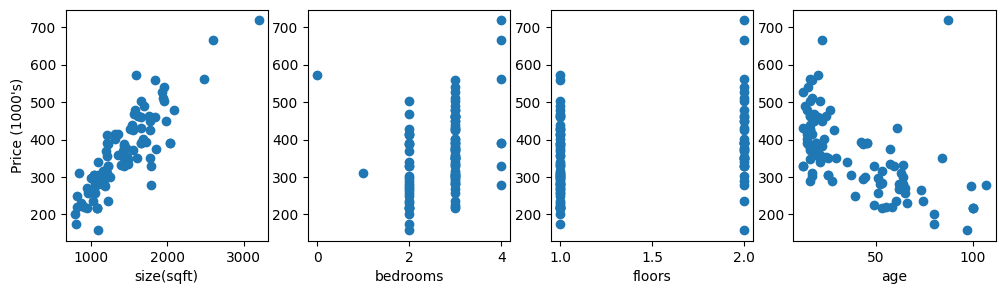

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
  ax[i].scatter(X_train[: , i], y_train)
  ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()


In [ ]:
m,n = X_train.shape
w_in = [0.1 , 1, 0.01, 0.2]
b_in = 10
print(m)
print(n)

100
4


In [ ]:
def compute_cost(x,y,w,b):
  m,_ = x.shape
  cost = 0
  for i in range(m):
    f_wb_i = np.dot(x[i] , w) + b
    j_wb = (f_wb_i - y[i]) ** 2
    cost += j_wb
  cost = cost / (2* m)
  return cost

In [ ]:
computed_cost = compute_cost(X_train, y_train, w_in, b_in)
print(computed_cost)

22933.18159824001


compute_gradient() → "Which direction should we move w and b?"

In [ ]:
def compute_gradient(x,y,w,b):
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb_i = np.dot(w , x[i]) + b
    f_wb = f_wb_i - y[i]
    dj_dw_i = f_wb * x[i]
    dj_db_i = f_wb
    dj_dw += dj_dw_i
    dj_db += dj_db_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [ ]:
dj_dw_, dj_db_ = compute_gradient(X_train, y_train, w_in, b_in)
print(dj_dw_)
print(dj_db_)

[-3.03511252e+05 -5.47539680e+02 -2.81064220e+02 -6.35592518e+03]
-200.41471999999993


In [ ]:
# Gradient Descent
def gradient_descent(x,y,w,b,alpha,iters,cost_fun, gradient_fun):
  cost_history = []

  for i in range(iters):
    dj_dw , dj_db = gradient_fun(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i <10000:
      cost_history.append(cost_fun(x,y,w,b))

    if i % math.ceil(iters/10) == 0:
      print(f"Iteration: {i:4d} , Cost: {cost_history[-1]}")

  return w, b, cost_history

In [ ]:
alpha_ = 9.9e-7
iterations = 10

In [ ]:
w_f, b_f, hist = gradient_descent(X_train, y_train, w_in, b_in, alpha_, iterations, compute_cost, compute_gradient)
print(w_f)
print(b_f)
print(hist[:10])

Iteration:    0 , Cost: 29684.511306444332
Iteration:    1 , Cost: 38582.55226273913
Iteration:    2 , Cost: 50309.81072630032
Iteration:    3 , Cost: 65765.7830662505
Iteration:    4 , Cost: 86135.94371158363
Iteration:    5 , Cost: 112982.66653038835
Iteration:    6 , Cost: 148365.05296227912
Iteration:    7 , Cost: 194996.85726595588
Iteration:    8 , Cost: 256454.62114761007
Iteration:    9 , Cost: 337451.9809044113
[-0.31608262  0.99913938  0.009515    0.18125977]
9.999753924019709
[np.float64(29684.511306444332), np.float64(38582.55226273913), np.float64(50309.81072630032), np.float64(65765.7830662505), np.float64(86135.94371158363), np.float64(112982.66653038835), np.float64(148365.05296227912), np.float64(194996.85726595588), np.float64(256454.62114761007), np.float64(337451.9809044113)]


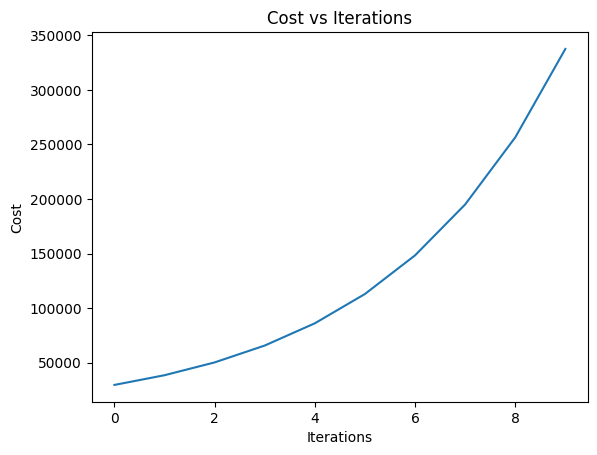

In [ ]:
plt.plot(hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

In [ ]:
alpha_1 = 1e-7

In [ ]:
w_f, b_f, hist = gradient_descent(X_train, y_train, w_in, b_in, alpha_1, iterations, compute_cost, compute_gradient)
print(w_f)
print(b_f)
print(hist[:10])

Iteration:    0 , Cost: 14716.984057033382
Iteration:    1 , Cost: 9679.318465617303
Iteration:    2 , Cost: 6590.520712510172
Iteration:    3 , Cost: 4696.641216691864
Iteration:    4 , Cost: 3535.4074230692313
Iteration:    5 , Cost: 2823.384045553897
Iteration:    6 , Cost: 2386.787110784098
Iteration:    7 , Cost: 2119.06365630299
Iteration:    8 , Cost: 1954.8823768770103
Iteration:    9 , Cost: 1854.1863905091523
[0.22777665 1.00022485 0.0101132  0.20215922]
10.00008583855913
[np.float64(14716.984057033382), np.float64(9679.318465617303), np.float64(6590.520712510172), np.float64(4696.641216691864), np.float64(3535.4074230692313), np.float64(2823.384045553897), np.float64(2386.787110784098), np.float64(2119.06365630299), np.float64(1954.8823768770103), np.float64(1854.1863905091523)]


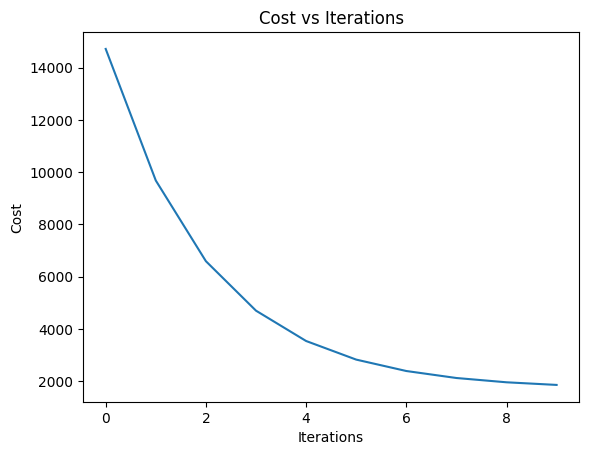

In [ ]:
plt.plot(hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

z score normalized function

In [ ]:
def zscore_normalize_features(X):
  mu = np.mean(X, axis = 0)
  sigma = np.std(X, axis = 0)
  X_norm = (X - mu) / sigma
  return (X_norm, mu, sigma)
